# Supply Chain Exploratory Data Analysis Using Python

Import the Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

Load the Dataset

In [2]:
raw_data = pd.read_csv("supply_chain_raw.csv")

In [3]:
data=raw_data.copy()

In [4]:
pd.options.display.max_columns = None
pd.options.display.max_rows = None

In [5]:
data.head()

,OrderID,ProductID,Warehouse,OrderQuantity,LeadTimeDays,ShippingDelayDays,SupplierRating,OrderDate
0,12000,293,Lagos_WH,409,6,6,1.9,2023-04-24
1,12001,285,Abuja_WH,483,9,9,1.5,2023-03-19
2,12002,186,Lagos_WH,400,18,0,2.8,2023-01-18
3,12003,171,Kano_WH,11,9,3,2.2,2023-05-19
4,12004,225,Kano_WH,343,23,6,1.9,2023-12-02


Checking the data structure

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OrderID            4500 non-null   int64  
 1   ProductID          4500 non-null   int64  
 2   Warehouse          4500 non-null   object 
 3   OrderQuantity      4500 non-null   int64  
 4   LeadTimeDays       4500 non-null   int64  
 5   ShippingDelayDays  4500 non-null   int64  
 6   SupplierRating     4351 non-null   float64
 7   OrderDate          4500 non-null   object 
dtypes: float64(1), int64(5), object(2)
memory usage: 281.4+ KB


In [7]:
data.describe()

,OrderID,ProductID,OrderQuantity,LeadTimeDays,ShippingDelayDays,SupplierRating
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4351.000000
mean,14249.500000,201.066222,251.870889,14.922667,4.462444,2.983659
std,1299.182435,57.679400,141.423753,8.361858,2.850059,1.154060
min,12000.000000,100.000000,10.000000,1.000000,0.000000,1.000000
25%,13124.750000,151.000000,130.000000,8.000000,2.000000,2.000000
50%,14249.500000,201.000000,248.000000,15.000000,4.000000,3.000000
75%,15374.250000,252.000000,374.000000,22.000000,7.000000,4.000000
max,16499.000000,299.000000,499.000000,29.000000,9.000000,5.000000


Handling Missing Values

In [8]:
data.isnull().sum()

OrderID                0
ProductID              0
Warehouse              0
OrderQuantity          0
LeadTimeDays           0
ShippingDelayDays      0
SupplierRating       149
OrderDate              0
dtype: int64

In [9]:
data['SupplierRating'].fillna(data['SupplierRating'].mean(), inplace=True)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OrderID            4500 non-null   int64  
 1   ProductID          4500 non-null   int64  
 2   Warehouse          4500 non-null   object 
 3   OrderQuantity      4500 non-null   int64  
 4   LeadTimeDays       4500 non-null   int64  
 5   ShippingDelayDays  4500 non-null   int64  
 6   SupplierRating     4500 non-null   float64
 7   OrderDate          4500 non-null   object 
dtypes: float64(1), int64(5), object(2)
memory usage: 281.4+ KB


Date Column Conversion

In [11]:
data['OrderDate'] = pd.to_datetime(data['OrderDate'])

In [12]:
data['Month'] = data['OrderDate'].dt.month
data['Year'] = data['OrderDate'].dt.year

In [13]:
data.head()

,OrderID,ProductID,Warehouse,OrderQuantity,LeadTimeDays,ShippingDelayDays,SupplierRating,OrderDate,Month,Year
0,12000,293,Lagos_WH,409,6,6,1.9,2023-04-24,4,2023
1,12001,285,Abuja_WH,483,9,9,1.5,2023-03-19,3,2023
2,12002,186,Lagos_WH,400,18,0,2.8,2023-01-18,1,2023
3,12003,171,Kano_WH,11,9,3,2.2,2023-05-19,5,2023
4,12004,225,Kano_WH,343,23,6,1.9,2023-12-02,12,2023


Checking Warehouse Distribution

In [14]:
data['Warehouse'].value_counts()

Abuja_WH    1523
Lagos_WH    1520
Kano_WH     1457
Name: Warehouse, dtype: int64

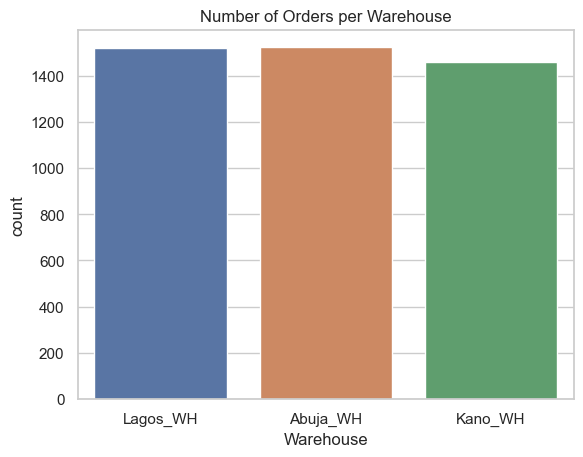

In [15]:
sns.countplot(x='Warehouse', data=data)
plt.title("Number of Orders per Warehouse")
plt.show()

Order Quantity Distribution

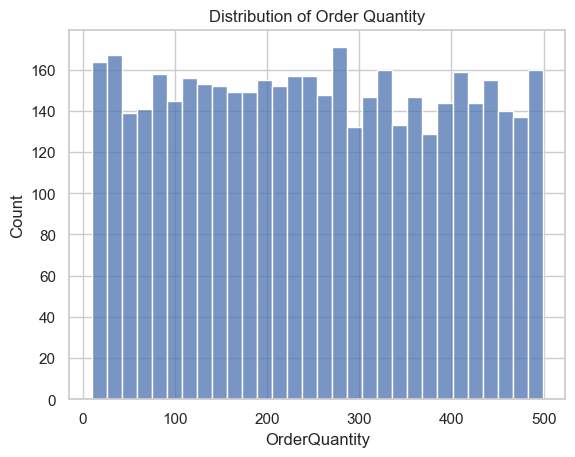

In [16]:
sns.histplot(data['OrderQuantity'], bins=30)
plt.title("Distribution of Order Quantity")
plt.show()

Shipping Delays

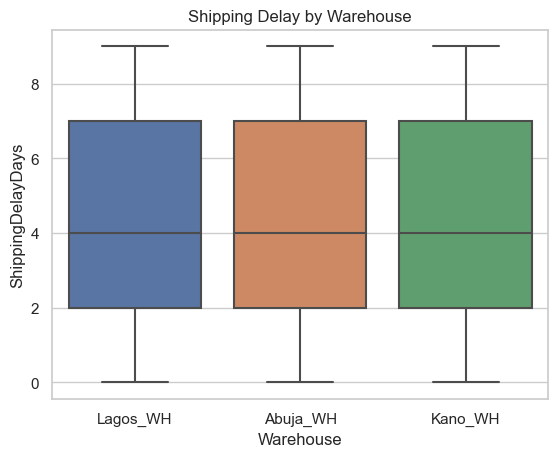

In [17]:
sns.boxplot(x='Warehouse', y='ShippingDelayDays', data=data)
plt.title("Shipping Delay by Warehouse")
plt.show()

Supplier Rating vs Shipping Delay

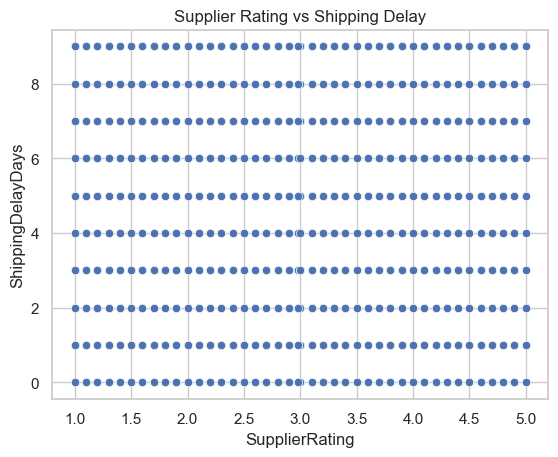

In [18]:
sns.scatterplot(x='SupplierRating', y='ShippingDelayDays', data=data)
plt.title("Supplier Rating vs Shipping Delay")
plt.show()

Monthly Order Trend

In [19]:
orders_per_month = data.groupby('Month')['OrderID'].count()

In [20]:
orders_per_month

Month
1     380
2     348
3     400
4     356
5     372
6     364
7     373
8     388
9     396
10    369
11    375
12    379
Name: OrderID, dtype: int64

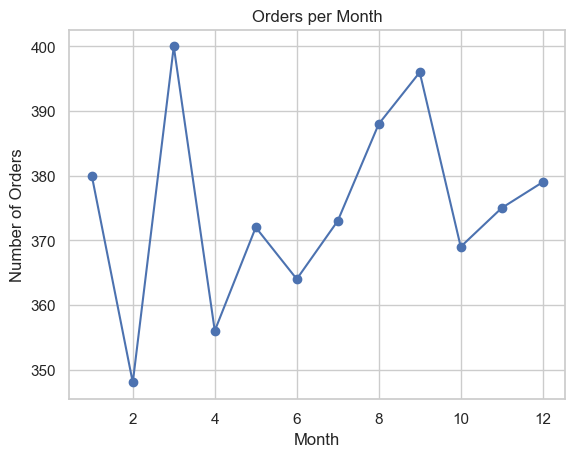

In [21]:
orders_per_month.plot(kind='line', marker='o')
plt.title("Orders per Month")
plt.ylabel("Number of Orders")
plt.show()

Product Sold Per Warehouse

In [22]:
product_warehouse_sales = data.groupby(['ProductID','Warehouse'])['OrderQuantity'].sum()
print(product_warehouse_sales)

ProductID  Warehouse
100        Abuja_WH     1834
           Kano_WH      1551
           Lagos_WH     2126
101        Abuja_WH     2639
           Kano_WH       866
           Lagos_WH     1038
102        Abuja_WH     1491
           Kano_WH      4077
           Lagos_WH     1446
103        Abuja_WH     2262
           Kano_WH      1605
           Lagos_WH     2131
104        Abuja_WH     1901
           Kano_WH      1034
           Lagos_WH      743
105        Abuja_WH     2404
           Kano_WH      1401
           Lagos_WH      889
106        Abuja_WH      975
           Kano_WH       515
           Lagos_WH     1615
107        Abuja_WH     1037
           Kano_WH      1352
           Lagos_WH     2372
108        Abuja_WH     2853
           Kano_WH      1125
           Lagos_WH     1537
109        Abuja_WH     2608
           Kano_WH      1864
           Lagos_WH     2081
110        Abuja_WH      712
           Kano_WH      1414
           Lagos_WH     2384
111        Abuja_WH   

In [23]:
pivot_table = data.pivot_table(values='OrderQuantity',
                             index='ProductID',
                             columns='Warehouse',
                             aggfunc='sum')

print(pivot_table)

Warehouse  Abuja_WH  Kano_WH  Lagos_WH
ProductID                             
100            1834     1551      2126
101            2639      866      1038
102            1491     4077      1446
103            2262     1605      2131
104            1901     1034       743
105            2404     1401       889
106             975      515      1615
107            1037     1352      2372
108            2853     1125      1537
109            2608     1864      2081
110             712     1414      2384
111            1666     1272      3285
112            1560     2166      1806
113            1877      825      1880
114            1819     1057       534
115            1502      520      3011
116             940      897      2002
117            1373      628      1498
118            1048     1468      2334
119             485     2176      2507
120            1506     1454      2837
121            1700     2326      3245
122            2667     2444      4095
123            2220      

In [24]:
top_warehouse = pivot_table.idxmax(axis=1)
print(top_warehouse)

ProductID
100    Lagos_WH
101    Abuja_WH
102     Kano_WH
103    Abuja_WH
104    Abuja_WH
105    Abuja_WH
106    Lagos_WH
107    Lagos_WH
108    Abuja_WH
109    Abuja_WH
110    Lagos_WH
111    Lagos_WH
112     Kano_WH
113    Lagos_WH
114    Abuja_WH
115    Lagos_WH
116    Lagos_WH
117    Lagos_WH
118    Lagos_WH
119    Lagos_WH
120    Lagos_WH
121    Lagos_WH
122    Lagos_WH
123    Abuja_WH
124    Lagos_WH
125    Abuja_WH
126     Kano_WH
127    Lagos_WH
128     Kano_WH
129    Abuja_WH
130    Abuja_WH
131    Abuja_WH
132    Abuja_WH
133    Lagos_WH
134     Kano_WH
135     Kano_WH
136     Kano_WH
137    Lagos_WH
138    Lagos_WH
139    Lagos_WH
140    Abuja_WH
141    Abuja_WH
142     Kano_WH
143     Kano_WH
144     Kano_WH
145    Abuja_WH
146     Kano_WH
147    Abuja_WH
148     Kano_WH
149     Kano_WH
150     Kano_WH
151    Abuja_WH
152     Kano_WH
153    Lagos_WH
154    Lagos_WH
155    Abuja_WH
156    Abuja_WH
157    Lagos_WH
158    Lagos_WH
159    Lagos_WH
160    Abuja_WH
161    Lagos_W

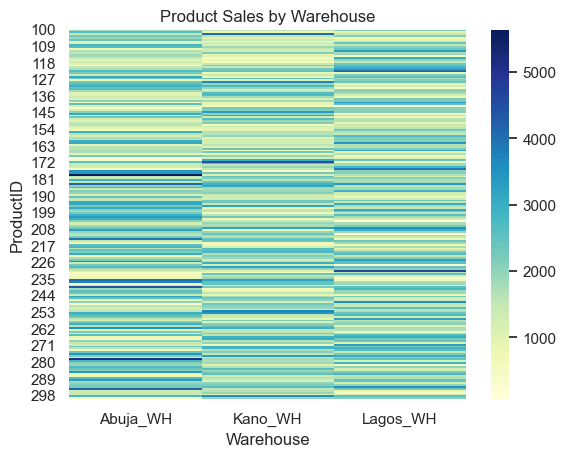

In [25]:
sns.heatmap(pivot_table, cmap="YlGnBu")
plt.title("Product Sales by Warehouse")
plt.show()

Correlation Analysis

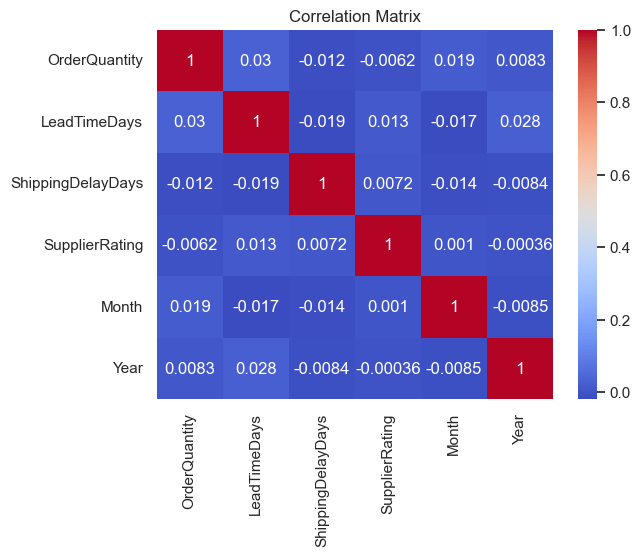

In [26]:
data_corr=data.copy()
data_corr = data_corr.drop(columns=['OrderID', 'ProductID'])
corr = data_corr.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [27]:
data.to_csv('Dashboard_data.csv', index=False)